In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/Users/anikatowsinrahi/Downloads/ai-adoption-fortune500-synthetic-dataset-2020-2025.csv')
df.head(10)

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27
5,2025,Amazon,E-commerce,USA,Real,Enterprise,2.017669e+11,Yes,Autonomous Driving,19.47,96
6,2020,Apple,Technology,USA,Real,Enterprise,7.965463e+10,Yes,Supply Chain Optimization,19.56,77
7,2021,Apple,Technology,USA,Real,Enterprise,3.344166e+11,Yes,Robotics,39.46,96
8,2022,Apple,Technology,USA,Real,Enterprise,4.072483e+11,Yes,Chatbots,13.94,94
9,2023,Apple,Technology,USA,Real,Enterprise,4.006746e+11,Yes,Fraud Detection,20.00,87


## Data Cleaning

In [4]:
print("Doing basic inquries to clean the data ")

Doing basic inquries to clean the data 


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               6000 non-null   int64  
 1   Company            6000 non-null   object 
 2   Industry           6000 non-null   object 
 3   Country            6000 non-null   object 
 4   Company_Type       6000 non-null   object 
 5   Employee_Size      6000 non-null   object 
 6   Revenue_USD        6000 non-null   float64
 7   Uses_AI            6000 non-null   object 
 8   Use_Case           4848 non-null   object 
 9   AI_ROI_Percent     6000 non-null   float64
 10  AI_Maturity_Score  6000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 515.8+ KB


In [6]:
print("Duplicates:")
print(df.duplicated().sum())

Duplicates:
0


In [7]:
print("Null Values:")
print(df.isnull().sum())

Null Values:
Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Case             1152
AI_ROI_Percent          0
AI_Maturity_Score       0
dtype: int64


In [8]:
print("Filling Null values with none")
df['Use_Case']=df['Use_Case'].fillna('None')

Filling Null values with none


In [9]:
df.dtypes

Year                   int64
Company               object
Industry              object
Country               object
Company_Type          object
Employee_Size         object
Revenue_USD          float64
Uses_AI               object
Use_Case              object
AI_ROI_Percent       float64
AI_Maturity_Score      int64
dtype: object

In [10]:
print("Number of Unique values of Columns :")
print(df[['Year','Country','Industry','Employee_Size']].apply(lambda x:x.nunique()))

Number of Unique values of Columns :
Year              6
Country          10
Industry         12
Employee_Size     2
dtype: int64


In [11]:
print("Industry Breakdown:")
print(df['Industry'].value_counts())


Industry Breakdown:
Industry
Technology        702
E-commerce        685
Finance           680
Telecom           670
Energy            667
Retail            653
Manufacturing     644
Healthcare        638
Logistics         631
Automotive         12
Consumer Goods     12
Industrial          6
Name: count, dtype: int64


In [12]:
print("Country Breakdown:")
print(df['Country'].value_counts())

Country Breakdown:
Country
USA            732
Canada         692
Brazil         686
India          662
China          660
UK             657
Germany        655
Japan          631
UAE            619
South Korea      6
Name: count, dtype: int64


In [13]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
              Year   Revenue_USD  AI_ROI_Percent  AI_Maturity_Score
count  6000.000000  6.000000e+03     6000.000000        6000.000000
mean   2022.500000  1.537110e+10       20.245257          54.491833
std       1.707967  4.400182e+10       12.657865          21.565809
min    2020.000000  1.010368e+06        0.000000           0.000000
25%    2021.000000  2.171382e+07       11.970000          43.000000
50%    2022.500000  4.255666e+07       21.480000          57.000000
75%    2024.000000  2.126462e+10       31.000000          71.000000
max    2025.000000  4.949976e+11       39.990000         100.000000


## Exploratory Data Analysis

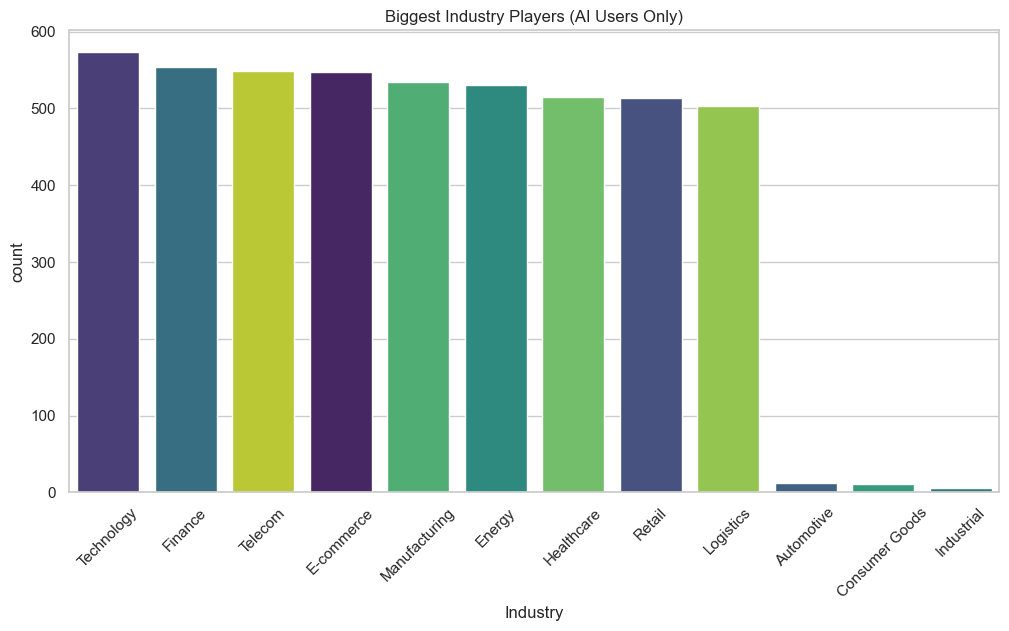

In [13]:
# which industry are the biggest players in using ai?
sns.set_theme(style="whitegrid")
df_ai_users = df[df["Uses_AI"] == "Yes"]
plt.figure(figsize=(12,6))
sns.countplot(x="Industry",data=df_ai_users,order=df_ai_users["Industry"].value_counts().index,palette="viridis",hue="Industry",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Biggest Industry Players (AI Users Only)")
plt.show()

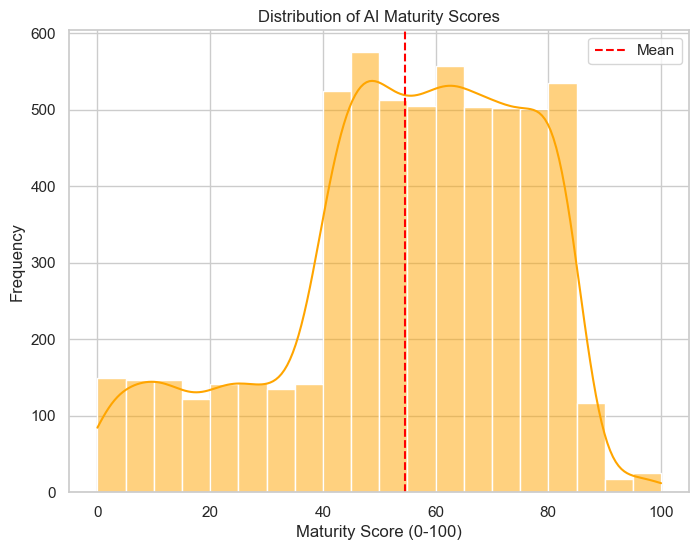

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.histplot(df['AI_Maturity_Score'], kde=True, color='orange', bins=20)
plt.axvline(df['AI_Maturity_Score'].mean(), color='red', linestyle='--', label='Mean')

plt.title('Distribution of AI Maturity Scores')
plt.xlabel('Maturity Score (0-100)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

                   AI_ROI_Percent  AI_Maturity_Score
AI_ROI_Percent           1.000000           0.614569
AI_Maturity_Score        0.614569           1.000000


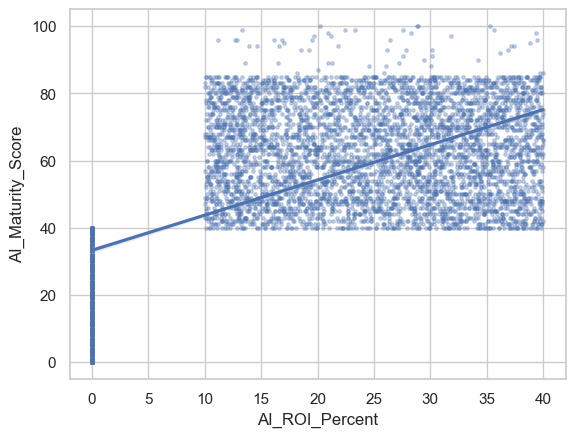

In [15]:
#Seeing relationship between AI_ROI_Percent and AI_Maturity_Score
sns.regplot(data=df, x="AI_ROI_Percent", y="AI_Maturity_Score", 
            scatter_kws={'alpha': 0.3, 's': 6})  
print(df[['AI_ROI_Percent', 'AI_Maturity_Score']].corr())

In [16]:
# Check correlation WITHOUT the zeros
print(df[df['AI_ROI_Percent'] > 0][['AI_ROI_Percent', 'AI_Maturity_Score']].corr())

                   AI_ROI_Percent  AI_Maturity_Score
AI_ROI_Percent           1.000000           0.002796
AI_Maturity_Score        0.002796           1.000000


Text(0.5, 0, 'Use Case')

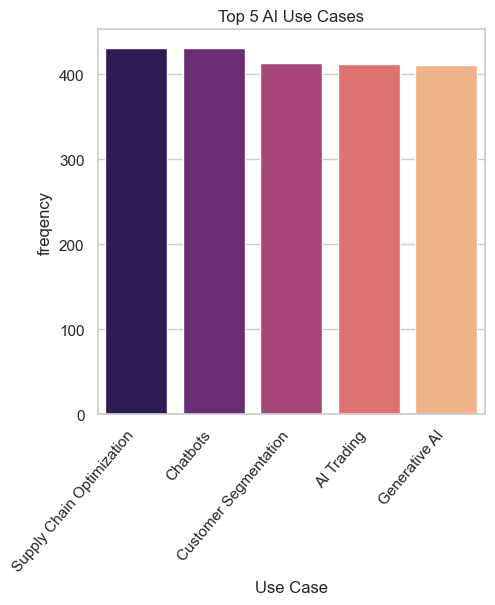

In [17]:
#top 5 use of ai 
sns.set_theme(style="whitegrid")
ai_use=df[df['Use_Case']!="None"]
top_5_ai_use=ai_use["Use_Case"].value_counts().head(5)
plt.figure(figsize=(5,5))
sns.barplot(y=top_5_ai_use.values, x=top_5_ai_use.index, palette="magma", hue=top_5_ai_use.index, legend=False)
plt.xticks(rotation=50,ha="right")
plt.title('Top 5 AI Use Cases')
plt.ylabel('freqency')
plt.xlabel('Use Case')



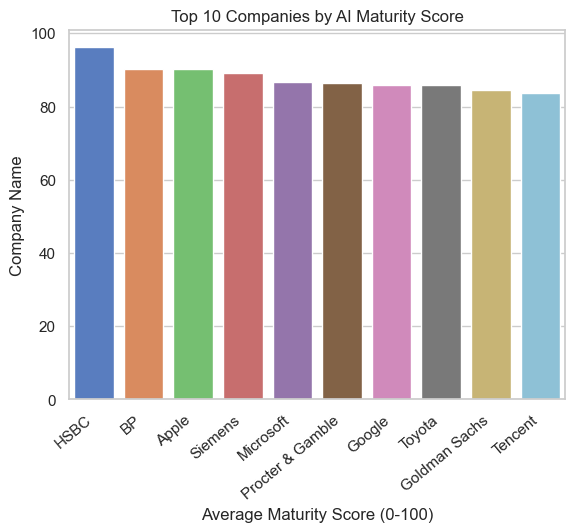

In [18]:
high_mature_ai_com = df.groupby('Company')['AI_Maturity_Score'].mean().sort_values(ascending=False).head(10)
sns.set_theme(style="whitegrid")
sns.barplot(y=high_mature_ai_com,x=high_mature_ai_com.index,palette="muted", hue=high_mature_ai_com.index, legend=False)
plt.title('Top 10 Companies by AI Maturity Score')
plt.xticks(rotation=40,ha="right")
plt.xlabel('Average Maturity Score (0-100)')
plt.ylabel('Company Name')
plt.show()







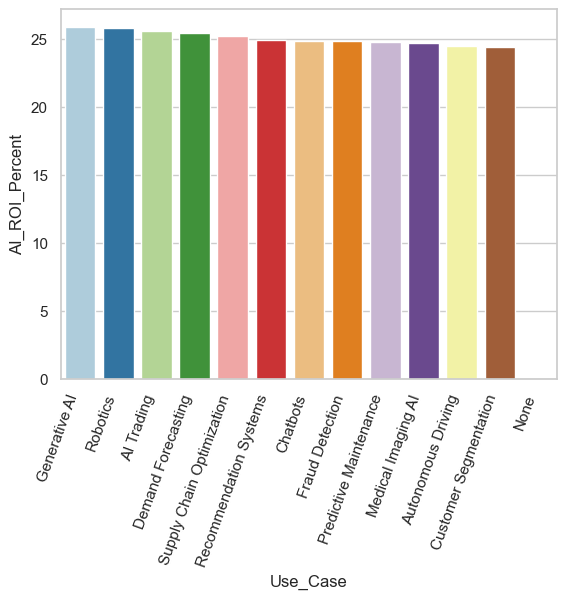

In [19]:
#use cases and their Ai ROI Percent

profit=df.groupby("Use_Case")["AI_ROI_Percent"].mean().sort_values(ascending=False)
sns.barplot(y=profit,x=profit.index,palette="Paired",hue=profit.index,legend=False)
plt.xticks(rotation=70,ha="right")
sns.set_theme(style="whitegrid")

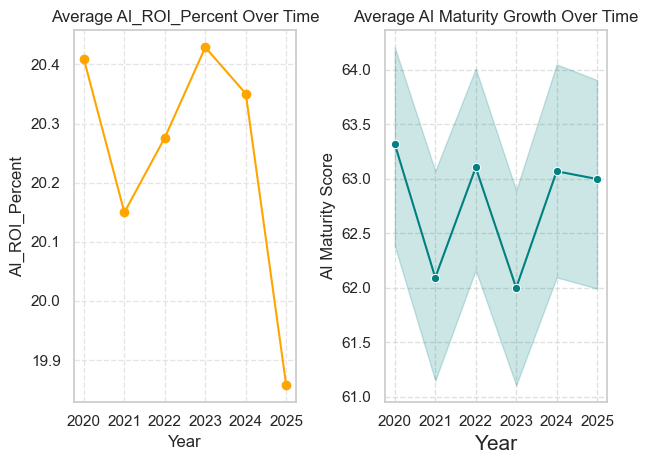

In [20]:
plt.subplot(1,2,1)
yearly_mean = df.groupby("Year")["AI_ROI_Percent"].mean()

plt.plot(yearly_mean.index, yearly_mean.values,marker="o",color="orange")

ax = plt.gca()
ax.set_xticks(yearly_mean.index)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Average AI_ROI_Percent Over Time',fontsize=12)
plt.xlabel("Year",fontsize=12)
plt.ylabel("AI_ROI_Percent",fontsize=12)
plt.subplot(1,2,2)
df_active = df[df['AI_ROI_Percent'] > 0]

# 3. Create the line plot
# 'Year' on x-axis, 'AI_Maturity_Score' on y-axis
sns.lineplot(data=df_active, x='Year', y='AI_Maturity_Score', marker='o', color='teal')

# 4. Add labels and title
plt.title('Average AI Maturity Growth Over Time', fontsize=12)
plt.xlabel('Year', fontsize=15)
plt.ylabel('AI Maturity Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
ax2 = plt.gca()
ax2.set_xticks(df_active['Year'].unique())  # Set x-ticks to unique years in the filtered dataframe
plt.tight_layout()
plt.show()


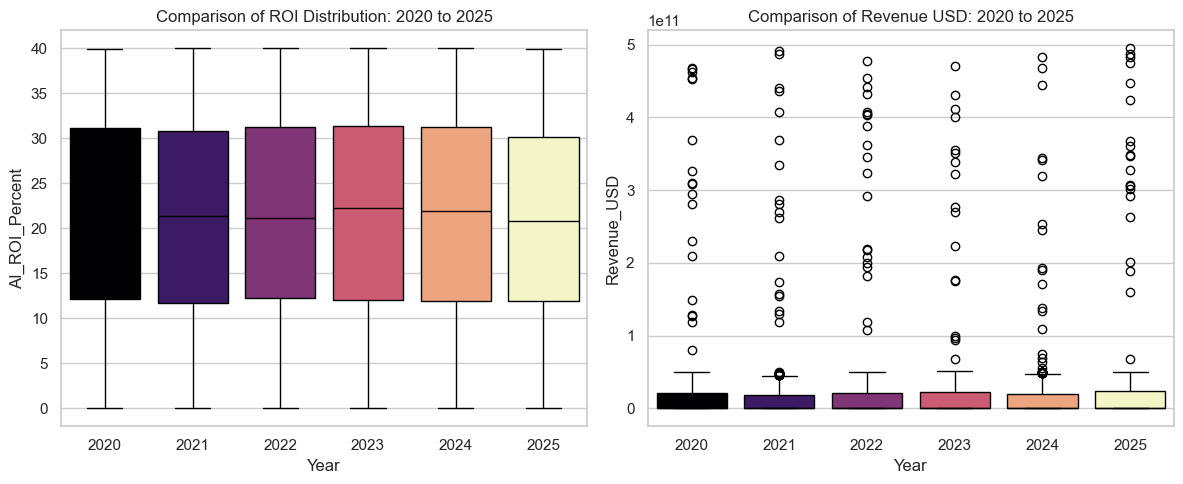

In [21]:
sns.set_theme(style="whitegrid")
# Compare 2020 to 2025 specifically
plt.figure(figsize=(12, 5))  

plt.subplot(1, 2, 1)  
sns.boxplot(data=df[df['Year'].isin([2020, 2021, 2022, 2023, 2024, 2025])], 
            x='Year', y='AI_ROI_Percent', palette="magma",hue="Year",legend=False)
plt.title("Comparison of ROI Distribution: 2020 to 2025")


plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['Year'].isin([2020, 2021, 2022, 2023, 2024, 2025])], 
            x='Year', y='Revenue_USD', palette="magma",hue="Year",legend=False) 
plt.title("Comparison of Revenue USD: 2020 to 2025")

plt.tight_layout() 
plt.show()  

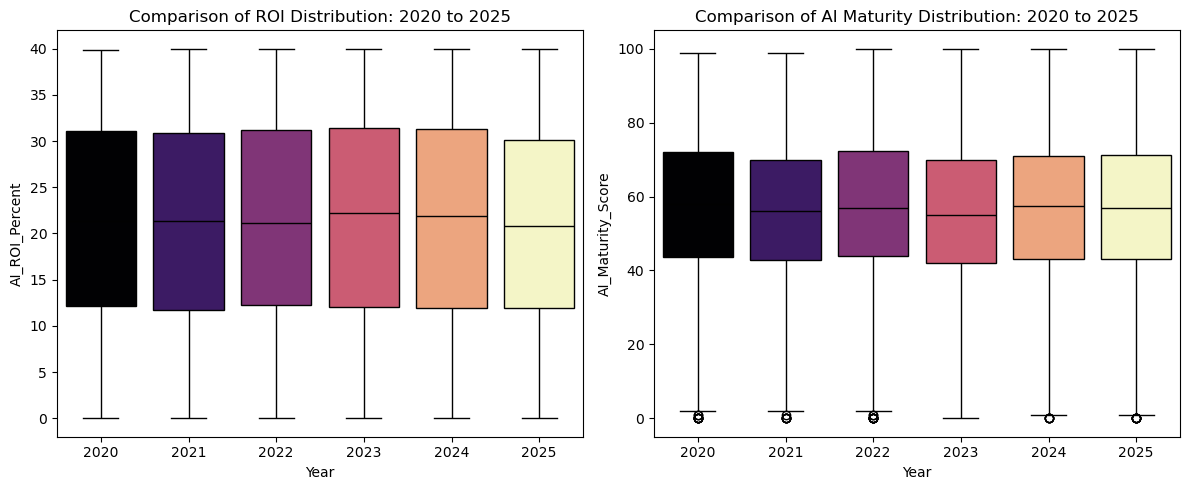

In [14]:

plt.figure(figsize=(12, 5))  
plt.subplot(1, 2, 1)  
sns.boxplot(data=df[df['Year'].isin([2020, 2021, 2022, 2023, 2024, 2025])], 
            x='Year', y='AI_ROI_Percent', palette="magma",hue='Year',legend=False)
plt.title("Comparison of ROI Distribution: 2020 to 2025")

plt.subplot(1, 2, 2)
sns.boxplot(data=df[df['Year'].isin([2020, 2021, 2022, 2023, 2024, 2025])], 
            x='Year', y='AI_Maturity_Score', palette="magma",hue='Year',legend=False) 
plt.title("Comparison of AI Maturity Distribution: 2020 to 2025")

plt.tight_layout()  

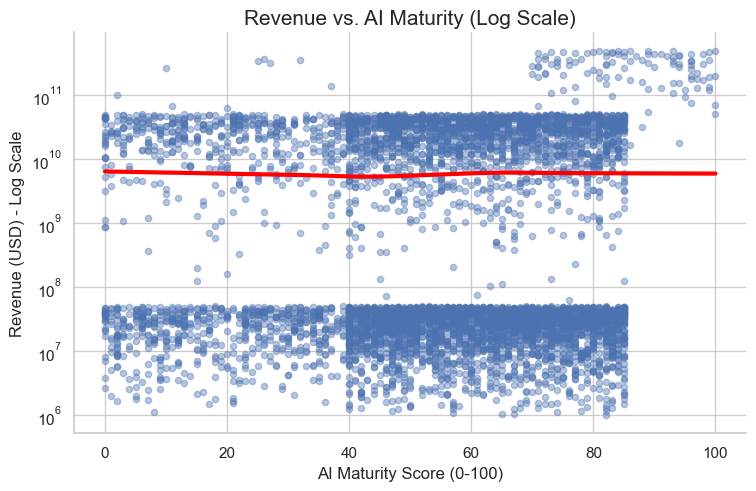

In [23]:
#Revenue VS AI_Maturity_Score
sns.set_theme(style="whitegrid")

g = sns.lmplot(x="AI_Maturity_Score", y="Revenue_USD", data=df, 
               lowess=True, aspect=1.5,
               line_kws={'color': 'red', 'linewidth': 3},
               scatter_kws={'alpha': 0.4, 's': 20})
plt.yscale('log')

plt.title("Revenue vs. AI Maturity (Log Scale)", fontsize=15)
plt.xlabel("AI Maturity Score (0-100)", fontsize=12)
plt.ylabel("Revenue (USD) - Log Scale", fontsize=12)

plt.show()

### Final conclusion:
##### Sector Dominance:The "Technology," "Finance," and "Telecom" sectors lead in volume,Conversely, traditional sectors like "Automotive" and "Industrial" show significantly lower representation in this dataset.
##### Top Performers: Companies such as HSBC, BP, and Apple emerge as leaders in AI Maturity, maintaining average scores near or above 90.
##### Correlation Paradox: While there is a general positive trend between AI Maturity and ROI (as seen in the initial regression), the correlation weakens significantly (r≈0.003) when excluding companies with 0% ROI. This suggests that while AI maturity is necessary, it is not a guaranteed driver of immediate ROI for all firms.
##### High-Yield Use Cases: Generative AI, Robotics, and AI Trading provide the highest average ROI (all hovering around 25%), indicating that specific applications of AI are more financially lucrative than others.
##### Scale Independence: The log-scale analysis of Revenue vs. AI Maturity shows that AI maturity is distributed across companies of all sizes.
##### Volatility in Growth: AI Maturity and ROI have not followed a perfectly linear path. There was a notable peak in maturity around 2023, followed by a slight stabilization.

##### Efficiency Gains: While ROI distribution has remained relatively stable (as shown in the boxplots), the consistency of high-revenue outcomes linked to AI has increased over the five-year period.The companies with Ai Matutity over 70 is mostly on the highest revenue.